<a href="https://colab.research.google.com/github/moiz-shahid/Deep-Learning-Tutorials/blob/main/Tutorial-04-Data-Augmentation/DL_Tutorial_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import random
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from google.colab import files

In [3]:
uploaded = files.upload()

image_name = list(uploaded.keys())[0]

print("Uploaded image:", image_name)

Saving DataAug.jpg to DataAug.jpg
Uploaded image: DataAug.jpg


In [4]:
save_folder = "/content/Augmented_Images"

os.makedirs(save_folder, exist_ok=True)

print("Save folder:", save_folder)

Save folder: /content/Augmented_Images


In [5]:
augmentation = transforms.Compose([
    transforms.RandomRotation(40),

    transforms.RandomAffine(
        degrees=0,
        shear=15,
        scale=(0.8, 1.2)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=(0.5, 1.5)
    )
])

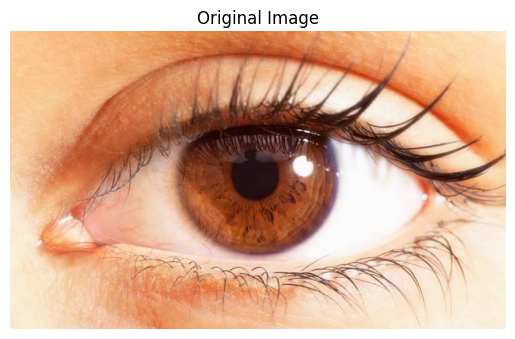

In [6]:
original_image = Image.open(image_name).convert("RGB")

plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [7]:
for i in range(40):

    augmented_image = augmentation(original_image)

    file_path = os.path.join(
        save_folder,
        f"augmented_{i + 1}.jpg"
    )

    augmented_image.save(file_path)

print("40 augmented images generated successfully.")

40 augmented images generated successfully.


In [8]:
saved_images = os.listdir(save_folder)

print("Number of augmented images:", len(saved_images))

Number of augmented images: 40


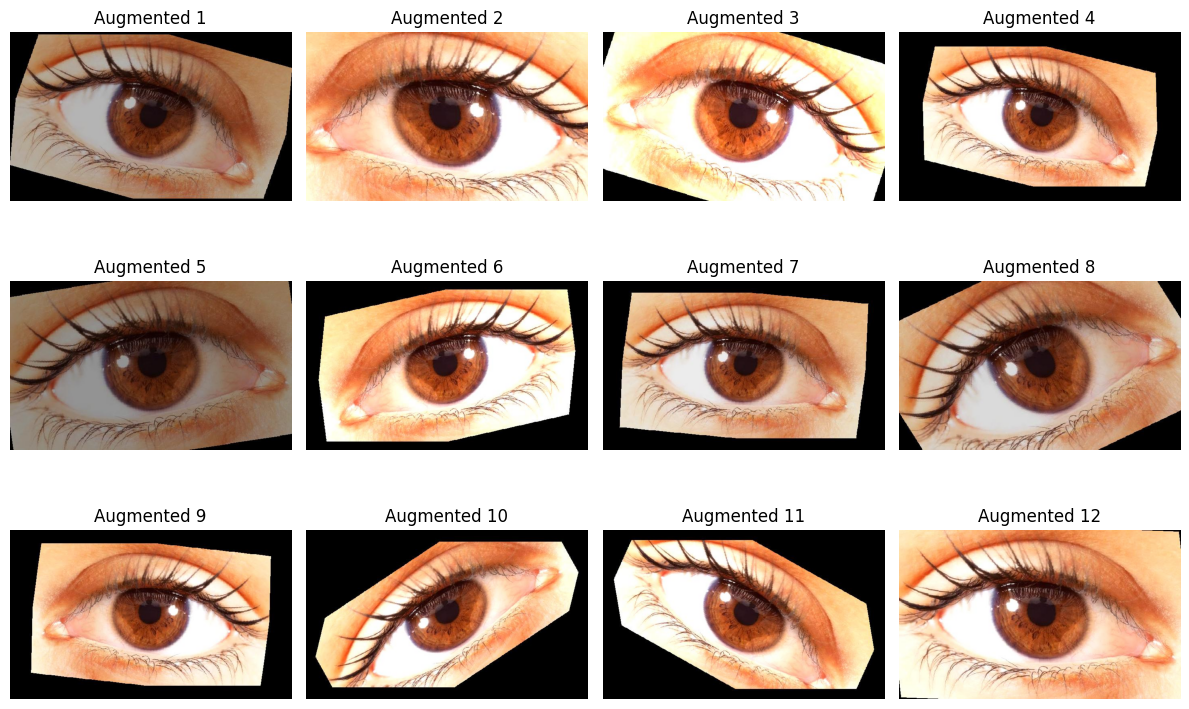

In [9]:
plt.figure(figsize=(12, 8))

for i, filename in enumerate(saved_images[:12]):

    image_path = os.path.join(
        save_folder,
        filename
    )

    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(f"Augmented {i + 1}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import shutil

shutil.make_archive(
    "/content/Augmented_Images",
    "zip",
    save_folder
)

files.download(
    "/content/Augmented_Images.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>